In [1]:
import pandas as pd 
import warnings
import matplotlib.pyplot as  plt 
import seaborn as sns 

warnings.filterwarnings('ignore')

In [22]:
df = pd.read_csv("data/employee_promotion.csv")

In [25]:
df.select_dtypes(["int","float"]).columns

Index(['Unnamed: 0', 'employee_id', 'age', 'years_at_company',
       'years_in_current_role', 'years_since_last_promotion', 'team_size',
       'performance_score', 'performance_last_year',
       'performance_two_years_ago', 'manager_rating', 'peer_feedback_score',
       'projects_completed', 'kpi_achievement_percent', 'innovation_score',
       'leadership_score', 'problem_solving_score', 'avg_monthly_hours',
       'overtime_hours', 'tasks_completed', 'deadline_adherence_rate',
       'meeting_hours_per_month', 'remote_work_ratio',
       'training_hours_last_year', 'certifications_count',
       'skill_assessment_score', 'cross_department_projects',
       'mentoring_sessions', 'salary', 'salary_increase_percent',
       'bonus_last_year', 'stock_options', 'attendance_rate', 'late_days',
       'employee_engagement_score', 'job_satisfaction_score',
       'internal_mobility_score', 'promoted'],
      dtype='object')

In [23]:
df.head()

,Unnamed: 0,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
0,0,1,50,Female,Master,Married,Tier1,Finance,Full-time,10,...,137633.720337,7.587737,16743.979863,7532.711623,0.930558,1,66.545499,97.588693,39.989458,0
1,1,2,36,Male,Bachelor,Married,Tier1,Sales,Full-time,9,...,114499.406460,10.372718,9074.413744,7694.310517,0.962302,7,81.979508,59.021333,46.484556,0
2,2,3,29,Female,Bachelor,Married,Tier2,Engineering,Full-time,7,...,124233.224752,10.115308,11807.910102,6380.645687,0.891287,1,100.000000,52.992147,38.850858,0
3,3,4,42,Male,Bachelor,Married,Tier1,Operations,Full-time,4,...,100896.326509,9.800044,8496.840118,7046.402195,1.000000,1,67.679942,67.707899,14.262315,0
4,4,5,40,Female,Master,Married,Tier1,Operations,Full-time,2,...,93054.051809,7.501102,15099.354711,4557.907600,0.896275,1,79.903505,64.384274,44.233443,0


In [8]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

print("Dataset Overview")
df.head()

Rows: 100000
Columns: 44
Dataset Overview


,Unnamed: 0,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
0,0,1,50,Female,Master,Married,Tier1,Finance,Full-time,10,...,137633.720337,7.587737,16743.979863,7532.711623,0.930558,1,66.545499,97.588693,39.989458,0
1,1,2,36,Male,Bachelor,Married,Tier1,Sales,Full-time,9,...,114499.406460,10.372718,9074.413744,7694.310517,0.962302,7,81.979508,59.021333,46.484556,0
2,2,3,29,Female,Bachelor,Married,Tier2,Engineering,Full-time,7,...,124233.224752,10.115308,11807.910102,6380.645687,0.891287,1,100.000000,52.992147,38.850858,0
3,3,4,42,Male,Bachelor,Married,Tier1,Operations,Full-time,4,...,100896.326509,9.800044,8496.840118,7046.402195,1.000000,1,67.679942,67.707899,14.262315,0
4,4,5,40,Female,Master,Married,Tier1,Operations,Full-time,2,...,93054.051809,7.501102,15099.354711,4557.907600,0.896275,1,79.903505,64.384274,44.233443,0


## Data Quality

In [9]:

null_number = df.isnull().sum().sum()
duplicate_number = df.duplicated().sum().sum()

print("Data Quality")
print(f"Null Value:{null_number}")
print(f"Duplicate numbers:{duplicate_number}")

print("\nWe can there is no null value and duplicate value")

Data Quality
Null Value:0
Duplicate numbers:0

We can there is no null value and duplicate value


## Numerical Summary Statistics 

In [9]:
numeric_columns = df.select_dtypes(["int","float"]).columns

print("Numerical statistics")
df[numeric_columns].describe().T

Numerical statistics


,count,mean,std,min,25%,50%,75%,max
employee_id,100000.0,50000.500000,28867.657797,1.000000,25000.750000,50000.500000,75000.250000,100000.000000
age,100000.0,40.558140,10.951788,22.000000,31.000000,41.000000,50.000000,59.000000
years_at_company,100000.0,5.489030,3.481758,0.000000,3.000000,5.000000,7.000000,30.000000
years_in_current_role,100000.0,2.750630,2.746004,0.000000,1.000000,2.000000,4.000000,28.000000
years_since_last_promotion,100000.0,2.749650,2.733337,0.000000,1.000000,2.000000,4.000000,29.000000
team_size,100000.0,11.014010,4.910633,3.000000,7.000000,11.000000,15.000000,19.000000
performance_score,100000.0,70.097429,14.717013,40.000000,59.499890,69.980013,80.596442,100.000000
performance_last_year,100000.0,68.166798,13.867294,40.000000,58.357646,68.033605,77.791895,100.000000
performance_two_years_ago,100000.0,65.102153,11.773939,40.000000,56.954026,65.018847,73.121749,100.000000
manager_rating,100000.0,3.302642,0.765938,1.000000,2.769433,3.302663,3.837462,5.000000


## Categorical columns 

In [10]:
categorical_columns = df.select_dtypes(["string","object"]).columns

print("Categorical columns")
df[categorical_columns].describe().T

Categorical columns


,count,unique,top,freq
gender,100000,2,Female,50071
education_level,100000,3,Bachelor,64767
marital_status,100000,2,Single,50093
city_tier,100000,3,Tier1,40215
department,100000,7,Finance,14542
employment_type,100000,2,Full-time,84884


## 

## Data Visualization

'\nSo with this figure we can say that this dataset is imbalance dataset \n'

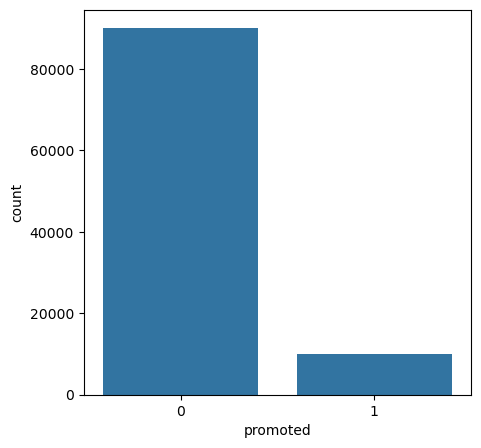

In [ ]:
# target columns i.e promoted

plt.figure(figsize=(5,5))
# barplot
sns.countplot(x=df["promoted"])
"""
So with this figure we can say that this dataset is imbalance dataset 
"""


In [10]:
cat_var = df.select_dtypes(["string","object"]).columns
cat_var 

Index(['gender', 'education_level', 'marital_status', 'city_tier',
       'department', 'employment_type'],
      dtype='object')

In [11]:
num_var = df.select_dtypes(["int","float"]).columns
num_var 

Index(['Unnamed: 0', 'employee_id', 'age', 'years_at_company',
       'years_in_current_role', 'years_since_last_promotion', 'team_size',
       'performance_score', 'performance_last_year',
       'performance_two_years_ago', 'manager_rating', 'peer_feedback_score',
       'projects_completed', 'kpi_achievement_percent', 'innovation_score',
       'leadership_score', 'problem_solving_score', 'avg_monthly_hours',
       'overtime_hours', 'tasks_completed', 'deadline_adherence_rate',
       'meeting_hours_per_month', 'remote_work_ratio',
       'training_hours_last_year', 'certifications_count',
       'skill_assessment_score', 'cross_department_projects',
       'mentoring_sessions', 'salary', 'salary_increase_percent',
       'bonus_last_year', 'stock_options', 'attendance_rate', 'late_days',
       'employee_engagement_score', 'job_satisfaction_score',
       'internal_mobility_score', 'promoted'],
      dtype='object')

In [12]:
df.select_dtypes(["string","object"])

,gender,education_level,marital_status,city_tier,department,employment_type
0,Female,Master,Married,Tier1,Finance,Full-time
1,Male,Bachelor,Married,Tier1,Sales,Full-time
2,Female,Bachelor,Married,Tier2,Engineering,Full-time
3,Male,Bachelor,Married,Tier1,Operations,Full-time
4,Female,Master,Married,Tier1,Operations,Full-time
...,...,...,...,...,...,...
99995,Male,Bachelor,Married,Tier1,HR,Full-time
99996,Female,PhD,Married,Tier1,Sales,Full-time
99997,Male,Master,Single,Tier1,Marketing,Full-time
99998,Female,Master,Single,Tier2,Operations,Full-time


In [13]:
df["gender"].value_counts()

gender
Female    50071
Male      49929
Name: count, dtype: int64

In [14]:
df["education_level"].unique()

array(['Master', 'Bachelor', 'PhD'], dtype=object)

In [15]:
df["marital_status"].unique()

array(['Married', 'Single'], dtype=object)

In [21]:
df["city_tier"].unique()

array(['Tier1', 'Tier2', 'Tier3'], dtype=object)

In [20]:
df["department"].unique()

array(['Finance', 'Sales', 'Engineering', 'Operations', 'HR', 'Marketing',
       'Support'], dtype=object)

In [19]:
df["employment_type"].unique()

array(['Full-time', 'Contract'], dtype=object)